In [2]:
#Regression is a supervised machine learning technique
#  used to predict continuous numerical values based on input features.

In [52]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [76]:
df = pd.read_csv("data/insurance.csv")

In [77]:
df.head(25)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [35]:
#Encode categorical columns
df = pd.get_dummies(df, drop_first=True)

In [36]:
#Define features and target
X = df.drop("charges", axis=1)
y = df["charges"]

In [38]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2,random_state=42 
)


In [39]:
#scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
#Evaluation function

def evaulate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)


    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [12]:
# Linear Regression
#Linear regression fits a straight line relationship between features and target.

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


pred_lr = lr.predict(X_test)

evaulate(y_test, pred_lr)

MAE: 4181.194473753652
MSE: 33596915.85136148
RMSE: 5796.284659276275
R2 Score: 0.7835929767120722


In [13]:
#Polynomial Regression
#Polynomial regression captures curved relationships.

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree =2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

pred_poly = poly_model.predict(X_test_poly)

evaulate(y_test, pred_poly)

MAE: 2729.5001336394544
MSE: 20712805.987918384
RMSE: 4551.132385233194
R2 Score: 0.866583090316484


In [14]:
#Ridge Regression (L2 Regularization)
#reduce overfitting

from sklearn.linear_model import Ridge

ridge = Ridge(alpha= 1.0)

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

evaulate(y_test, pred_ridge)

MAE: 4182.796596583271
MSE: 33604973.53996333
RMSE: 5796.979691180859
R2 Score: 0.7835410749121385


In [15]:
# Lasso Regression (L1 Regulariztion)
#Make some weight to 0 and feture selection

from sklearn.linear_model import Lasso

lasso = Lasso(alpha= 0.1)

lasso.fit(X_train,y_train)

pred_lasso = lasso.predict(X_test)

evaulate(y_test, pred_lasso)

MAE: 4181.226050965702
MSE: 33597337.5568425
RMSE: 5796.321036385278
R2 Score: 0.7835902603904832


In [16]:
#Elastic Net
#combination of Ridge + Lasso

from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

evaulate(y_test, pred_elastic)

MAE: 4275.656574439204
MSE: 34267911.94437556
RMSE: 5853.880076015869
R2 Score: 0.779270905371672


In [17]:
#Decision Tree Regression
# Splits data into smaller groups and makes predictions based on rules

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

#train
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

evaulate(y_test, pred_dt)

MAE: 3114.1529092761198
MSE: 40795333.45408598
RMSE: 6387.122470572017
R2 Score: 0.7372259788399772


In [18]:
#Random Forest Regression
#Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

evaulate(y_test, pred_rf)

MAE: 2543.9758251029275
MSE: 20864569.513376206
RMSE: 4567.775116331386
R2 Score: 0.8656055394920775


In [97]:
#Gradient Boosting
# Trees trained sequentially to fix previous errors.

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

evaulate(y_test, pred_gb)

MAE: 2454.473809214537
MSE: 18792571.226919454
RMSE: 4335.039933716811
R2 Score: 0.8789518532850926


In [20]:
#Support Vector Regression
#Margin-based prediction method.

from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train, y_train)

pred_svr = svr.predict(X_test)

evaulate(y_test, pred_svr)

MAE: 8612.408423351833
MSE: 166128803.80848217
RMSE: 12889.096314656128
R2 Score: -0.07008155372454805


In [22]:
#KNN Regression
# Prediction based on nearest neighbors

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

evaulate(y_test, pred_knn)

MAE: 3494.746057742537
MSE: 30459865.823198732
RMSE: 5519.045734834848
R2 Score: 0.8037995832203448


In [98]:
#Comparison Table

results = []

models = {
    "Linear Regression": pred_lr,
    "Polynomial": pred_poly,
    "Ridge": pred_ridge,
    "Lasso": pred_lasso,
    "ElasticNet": pred_elastic,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gb,
    "SVR": pred_svr,
    "KNN": pred_knn
}

for name, pred in models.items():
    r2 = r2_score(y_test, pred)
    results.append([name, r2])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score"])

results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

               Model  R2 Score
7  Gradient Boosting  0.878952
1         Polynomial  0.866583
6      Random Forest  0.865606
9                KNN  0.803800
0  Linear Regression  0.783593
3              Lasso  0.783590
2              Ridge  0.783541
4         ElasticNet  0.779271
5      Decision Tree  0.737226
8                SVR -0.070082


In [99]:
best_model = gb   # or whichever is best

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2454.473809214537
MSE: 18792571.226919454
RMSE: 4335.039933716811
R2: 0.8789518532850926


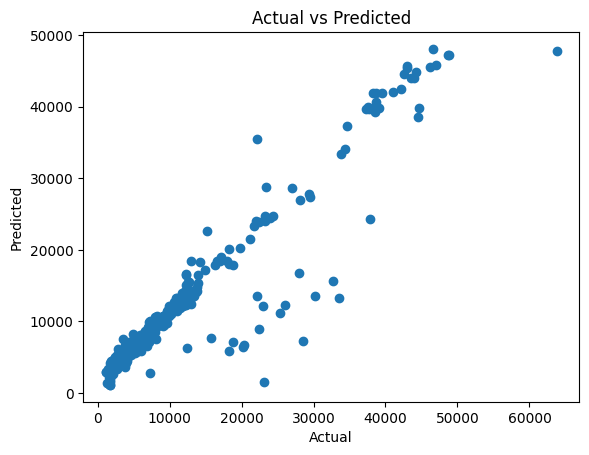

In [101]:
#Visualize

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

plt.show()

In [102]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [103]:
new_data = pd.DataFrame([{
    "age": 30,
    "bmi": 25,
    "children": 1,
    "sex_male": 1,
    "smoker_yes": 1,
    "region_northwest": 0,
    "region_southeast": 1,
    "region_southwest": 0
}])

# Match columns
columns = joblib.load("columns.pkl")
new_data = new_data.reindex(columns=columns, fill_value=0)

# Scale
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = best_model.predict(new_data_scaled)

print("Predicted Cost:", prediction[0])

Predicted Cost: 18505.451951656392


In [104]:
# smoker = no
smoker_no = new_data.copy()
smoker_no["smoker_yes"] = 0

# smoker = yes
smoker_yes = new_data.copy()
smoker_yes["smoker_yes"] = 1

print("No:", best_model.predict(scaler.transform(smoker_no))[0])
print("Yes:", best_model.predict(scaler.transform(smoker_yes))[0])

No: 6275.513769448989
Yes: 18505.451951656392
